In [49]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [27]:
import matplotlib.pyplot as plt

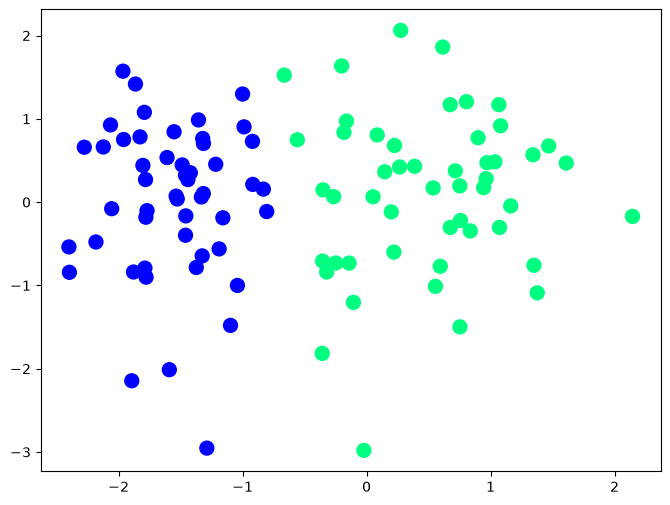

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

In [29]:
def step(z):
    return 1 if z > 0 else 0

In [30]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.ones(X.shape[1])  # Initialize weights
    lr = 0.1  # Learning rate

    for i in range(1000) : # number of epochs
        j = np.random.randint(0, X.shape[0])  # Randomly select a sample
        y_hat = step(np.dot(X[j], weights)) # Make prediction
        weights = weights + lr * (y[j] - y_hat) * X[j]  # Update weights, moving the line into either positive region or negative region

    return weights[0], weights[1:]  # Return bias and weights

In [31]:
intercept, coef_  = perceptron(X, y)

In [32]:
intercept

np.float64(1.0)

In [33]:
coef_

array([1.29777848, 0.14453731])

In [ ]:
# to have the line equation in the form of y = mx + b, we can rearrange the equation as follows:
m = -coef_[0] / coef_[1]
b = -intercept / coef_[1]

In [47]:
x_input = np.linspace(-3, 3, 100) # this will create 100 points between -3 and 3 for the x-axis
y_input = m * x_input + b # this will calculate the corresponding y values for each x value based on the line equation

(-3.0, 2.0)

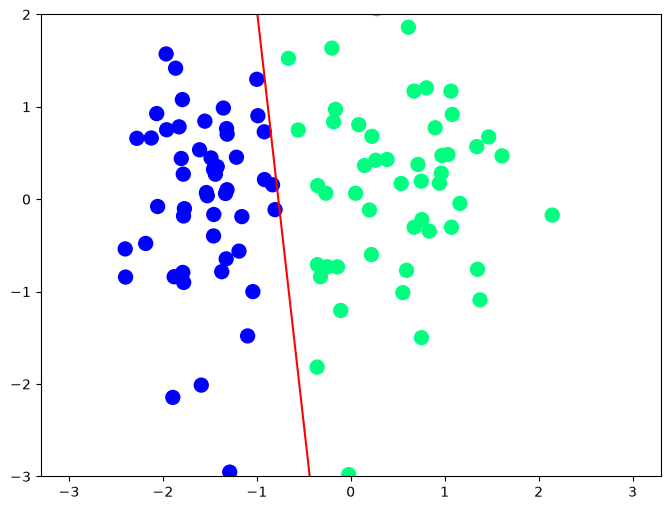

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(x_input, y_input, color='red', label='Decision Boundary')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)

In [50]:
def perceptron(X,y):
    m = []
    b = []

    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.ones(X.shape[1])  # Initialize weights
    lr = 0.1  # Learning rate

    for i in range(1000) : # number of epochs
        j = np.random.randint(0, X.shape[0])  # Randomly select a sample
        y_hat = step(np.dot(X[j], weights)) # Make prediction
        weights = weights + lr * (y[j] - y_hat) * X[j]  # Update weights, moving the line into either positive region or negative region

        m.append(-weights[1] / weights[2])
        b.append(-weights[0] / weights[2])

    return m, b  # Return bias and weights

In [51]:
m, b = perceptron(X, y)

In [52]:
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

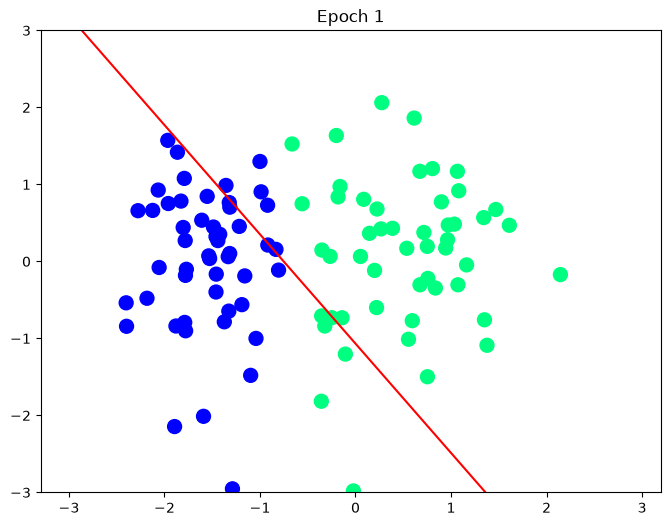

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

x_i = np.arange(-3, 3, 0.1)
y_i = m[0] * x_i + b[0]
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, x_i * m[0] + b[0], 'r-', label='Decision Boundary')
plt.ylim(-3, 3)

def update(frame):
    label = 'Epoch {0}'.format(frame+1)
    line.set_ydata(m[frame] * x_i + b[frame])
    ax.set_title(label)

anim = FuncAnimation(fig, update, frames=len(m), interval=100, repeat=True)
anim.save('perceptron_animation.gif', writer='pillow', fps=30)